# **Risk budget: concentration caps on the FCF + NAV SMA book**

The 12-config search in paper 07 picked a SUE satellite on train Calmar. We are **not** taking that. The book we will actually risk-check is **config 8**:

- **Engine:** paper 01 FCF quality (top half of Halal names by FCF margin, cap-weighted, monthly)
- **Brake:** 200-day SPY SMA on the **whole NAV** (`throttle="spy_sma"`). When SPY is below the average, the book is cash.
- **Not in the book:** ROIC, dual-momentum as a sleeve weight, SUE

That design already cut full-sample max drawdown from about −29% (always-on FCF) to about −9%, and 2022 from −24% to −3%. The remaining risk is **concentration**: top five names still held about **56%** of the invested book. One name, one sector, or a late SMA signal can still hurt.

Paper 08 asks: after Halal screens and the NAV throttle, does a **single-name cap** (5% / 8% / 10% / 15%) cut that pile-up without giving back the drawdown win?

**Frozen (do not retune here):** FCF live rule, AAOIFI screens, SMA window 200, 10 bp costs, 2% risk-free, train 2020–2022 / test 2023–2024.

**What we change:** `name_cap` only.

**Risk questions, in order:**

1. When is the book in cash, and how much of 2020/2022 did the SMA miss because it is slow?
2. How concentrated is the invested book (top 1, top 5, HHI, sector)?
3. What is left-tail risk versus SPY and SPUS (vol, CVaR, max DD, beta, down-capture)?
4. Do name caps improve those tails, or only shuffle mega-caps into the next ten names?

**White-paper question:** is the live risk budget “FCF + SMA, uncapped” or “FCF + SMA, 8% name cap”?


## Setup

Reuse paper 07 cached metrics and prices. Do not refetch ROIC or SUE — they are not in this book.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import display


def resolve_notebook_dir() -> Path:
    candidates = [Path.cwd()]
    candidates.append(
        Path.home() / "Documents/Development/Monterey-Finance/Research/papers/08-risk-budget"
    )
    for path in candidates:
        try:
            resolved = path.resolve()
        except OSError:
            continue
        if resolved.is_dir() and (resolved / "code.ipynb").exists():
            return resolved
    return Path.cwd()


NB_DIR = resolve_notebook_dir()
os.chdir(NB_DIR)

REPO_ROOT = NB_DIR.parents[2]
RESEARCH_ROOT = NB_DIR.parents[1]
PAPER07 = RESEARCH_ROOT / "papers" / "07-book-construction"
HQ_ROOT = REPO_ROOT.parent / "halalquant"
PIP_DEPS = ["yfinance", "matplotlib", "requests", "pyarrow", "duckdb"]

if HQ_ROOT.is_dir() and (HQ_ROOT / "pyproject.toml").exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", f"{HQ_ROOT}[cache]"],
        cwd=str(NB_DIR),
        check=False,
    )
    if str(HQ_ROOT) not in sys.path:
        sys.path.insert(0, str(HQ_ROOT))

subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + PIP_DEPS, cwd=str(NB_DIR), check=False)

if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))

import importlib
import sleeves
import sleeves.book
import sleeves.compliance
import sleeves.lab
import sleeves.select

importlib.reload(sleeves.compliance)
importlib.reload(sleeves.select)
importlib.reload(sleeves.book)
importlib.reload(sleeves.lab)
importlib.reload(sleeves)

os.environ.setdefault(
    "HALALQUANT_SEC_UA",
    "Monterey Finance Research halalquant/0.1.0 research@montereyfinance.com",
)

import warnings

import halalquant as hq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sleeves import FrozenRules, Lab, calc_performance_stats
from sleeves.prices import spy_sma_risk_on
from sleeves.universe import apply_sector_screen, load_sp500_tickers

warnings.filterwarnings("ignore", category=FutureWarning)

START = "2019-12-19"
END = "2024-12-31"
PRICE_START = "2018-01-01"
TRAIN_START, TRAIN_END = "2020-01-01", "2022-12-31"
TEST_START, TEST_END = "2023-01-01", "2024-12-31"
RISK_FREE_RATE = 0.02
COST_BPS = 10
SMA_WINDOW = 200
ENGINE_WEIGHTS = {"fcf_quality": 1.0}
THROTTLE = "spy_sma"
CAPS = [None, 0.15, 0.10, 0.08, 0.05]
FAST_MODE = False
BENCHMARKS = {"S&P 500": "SPY", "Halal (SPUS)": "SPUS"}

CACHE_DIR = PAPER07 / "cache"
FIG_DIR = NB_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"notebook dir: {NB_DIR}")
print(f"data cache:   {CACHE_DIR}")
print(f"Book: FCF 100%  throttle={THROTTLE}  caps={CAPS}")



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


notebook dir: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/08-risk-budget
data cache:   /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/07-book-construction/cache
Book: FCF 100%  throttle=spy_sma  caps=[None, 0.15, 0.1, 0.08, 0.05]


## Step 1 — Load frames and build the lab


In [2]:
metrics = pd.read_parquet(CACHE_DIR / "metrics.parquet")
prices = pd.read_parquet(CACHE_DIR / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
print(f"metrics {metrics.shape}  prices {prices.shape}")

raw_universe = load_sp500_tickers()
if FAST_MODE:
    raw_universe = raw_universe[:60]
eligible_universe, sector_audit, sector_map = apply_sector_screen(raw_universe)
print(f"Sector map names: {len(sector_map)}")

rules = FrozenRules().with_book(
    sleeve_weights=ENGINE_WEIGHTS,
    name_cap=None,
    throttle=THROTTLE,
    collapse_share_classes=True,
    cost_bps=COST_BPS,
    risk_free_rate=RISK_FREE_RATE,
    rebalance_freq="ME",
)

lab = Lab.from_frames(metrics, prices, rules=rules, start=START, end=END)
print("Lab ready. Last FCF snapshot:", lab.evaluate(pd.to_datetime(metrics["as_of"]).max(), sleeves=("fcf_quality",))["fcf_quality"].n_holdings, "names")


metrics (25600, 21)  prices (778360, 8)
Sector map names: 502
Lab ready. Last FCF snapshot: 121 names


## Step 2 — Risk helpers

CVaR is the mean of the worst 5% of daily returns. HHI is the sum of squared weights on an invested snapshot (1.0 = one name). Effective N is `1 / HHI`.


In [3]:
def to_series(frame, col="return") -> pd.Series:
    s = frame.dropna(subset=[col]).set_index("date")[col].astype(float)
    s.index = pd.to_datetime(s.index)
    return s.sort_index()


def sl(s, a, b):
    return s[(s.index >= pd.Timestamp(a)) & (s.index <= pd.Timestamp(b))].dropna()


def cagr(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    years = len(s) / 252
    return float((1 + s).prod() ** (1 / years) - 1) if years > 0 else np.nan


def max_dd(s):
    eq = (1 + s.dropna()).cumprod()
    if eq.empty:
        return np.nan
    return float((eq / eq.cummax() - 1).min())


def cvar(s, q=0.05):
    s = s.dropna()
    if len(s) < 20:
        return np.nan
    cutoff = s.quantile(q)
    tail = s[s <= cutoff]
    return float(tail.mean()) if len(tail) else np.nan


def ulcer(s):
    eq = (1 + s.dropna()).cumprod()
    if eq.empty:
        return np.nan
    dd = eq / eq.cummax() - 1
    return float(np.sqrt((dd ** 2).mean()))


def beta_capture(s, mkt):
    aligned = pd.concat([s.rename("y"), mkt.rename("x")], axis=1).dropna()
    if len(aligned) < 60:
        return {"beta": np.nan, "up_cap": np.nan, "down_cap": np.nan}
    y, x = aligned["y"], aligned["x"]
    varx = float(x.var())
    beta = float(y.cov(x) / varx) if varx > 0 else np.nan
    up = x > 0
    down = x < 0
    up_cap = float(y[up].mean() / x[up].mean()) if up.any() and x[up].mean() != 0 else np.nan
    down_cap = float(y[down].mean() / x[down].mean()) if down.any() and x[down].mean() != 0 else np.nan
    return {"beta": beta, "up_cap": up_cap, "down_cap": down_cap}


def conc_from_log(log: pd.DataFrame) -> dict:
    if log is None or log.empty:
        return {"top1": np.nan, "top5": np.nan, "hhi": np.nan, "eff_n": np.nan, "n_names": np.nan}
    rows = []
    for as_of, g in log.groupby("as_of"):
        w = g.groupby("symbol")["weight"].sum()
        w = w[w > 0]
        if w.empty:
            continue
        w = w / w.sum()
        hhi = float((w ** 2).sum())
        rows.append(
            {
                "top1": float(w.max()),
                "top5": float(w.nlargest(min(5, len(w))).sum()),
                "hhi": hhi,
                "eff_n": (1 / hhi) if hhi > 0 else np.nan,
                "n_names": int(len(w)),
            }
        )
    if not rows:
        return {"top1": np.nan, "top5": np.nan, "hhi": np.nan, "eff_n": np.nan, "n_names": np.nan}
    d = pd.DataFrame(rows)
    return {k: float(d[k].mean()) for k in d.columns}


def calendar_return(s, year):
    x = sl(s, f"{year}-01-01", f"{year}-12-31")
    return float((1 + x).prod() - 1) if not x.empty else np.nan


bench_px = (
    prices[prices["symbol"].isin(BENCHMARKS.values())]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
bench_ret = bench_px.pct_change(fill_method=None)
spy = sl(bench_ret["SPY"].dropna(), START, END)
spus = sl(bench_ret["SPUS"].dropna(), START, END)


## Step 3 — Config 8 baseline (FCF 100%, SMA on NAV, no cap)

This is the book. Everything below is measured against it.


In [4]:
print("Running config 8 — FCF 100%, throttle=spy_sma, name_cap=None …")
base_ret, base_log = lab.book(
    sleeve_weights=ENGINE_WEIGHTS, name_cap=None, throttle=THROTTLE
).run(start=START)
base = to_series(base_ret)
live = sl(base, START, END)
fcf_on_ret, fcf_on_log = lab.book(
    sleeve_weights=ENGINE_WEIGHTS, name_cap=None, throttle=None
).run(start=START)
fcf_on = to_series(fcf_on_ret)

cash_days = base_ret.dropna(subset=["return"])
cash_days = cash_days[(pd.to_datetime(cash_days["date"]) >= pd.Timestamp(START))]
in_cash = cash_days["n_holdings"].fillna(0).eq(0)
print(f"Live days: {len(cash_days)}  days in cash: {int(in_cash.sum())} ({in_cash.mean():.1%})")

spy_s = lab.spy_series()
regime = pd.Series(
    [spy_sma_risk_on(spy_s, dt, SMA_WINDOW) for dt in spy_s.index],
    index=pd.to_datetime(spy_s.index),
)
regime = regime[(regime.index >= pd.Timestamp(START)) & (regime.index <= pd.Timestamp(END))]
print(f"SPY above 200d SMA: {regime.mean():.1%} of days")

# 2020 crash window: peak-to-trough on SPY
spy_eq = (1 + spy).cumprod()
crash = spy_eq.loc["2020-01-01":"2020-06-30"]
trough_dt = crash.idxmin()
print(f"SPY 2020 trough date: {trough_dt.date()}  SPY DD {float(crash.min() / crash.iloc[0] - 1):.1%}")
print(f"  SMA risk-on that day: {bool(regime.asof(trough_dt)) if len(regime) else False}")

stats_base = calc_performance_stats(live, "Config 8 FCF+SMA", rf=RISK_FREE_RATE)
stats_on = calc_performance_stats(sl(fcf_on, START, END), "FCF always on", rf=RISK_FREE_RATE)
cap8 = beta_capture(live, spy)
conc8 = conc_from_log(base_log)
print("\nConfig 8 vs always-on FCF:")
for lab_s, st in (("FCF+SMA", stats_base), ("FCF on", stats_on)):
    print(f"  {lab_s:10s} CAGR {st['CAGR']:.1%}  vol {st['Volatility']:.1%}  maxDD {st['Max Drawdown']:.1%}  Calmar {st['Calmar']:.2f}")
print(
    f"  CVaR 5% {cvar(live):.2%}  ulcer {ulcer(live):.2%}  "
    f"beta vs SPY {cap8['beta']:.2f}  up/down capture {cap8['up_cap']:.2f}/{cap8['down_cap']:.2f}"
)
print(
    f"  mean top1 {conc8['top1']:.1%}  top5 {conc8['top5']:.1%}  "
    f"HHI {conc8['hhi']:.3f}  effective N {conc8['eff_n']:.1f}  names {conc8['n_names']:.0f}"
)

last = pd.to_datetime(base_log["as_of"]).max()
last_snap = base_log[pd.to_datetime(base_log["as_of"]) == last].copy()
last_snap["sector"] = last_snap["symbol"].map(sector_map).fillna("Unclassified")
print(f"\nLast invested snapshot {last.date()} — largest names:")
display(last_snap.sort_values("weight", ascending=False).head(12)[["symbol", "weight", "sector"]])


Running config 8 — FCF 100%, throttle=spy_sma, name_cap=None …
Live days: 1259  days in cash: 326 (25.9%)
SPY above 200d SMA: 78.0% of days
SPY 2020 trough date: 2020-03-23  SPY DD -31.0%
  SMA risk-on that day: False

Config 8 vs always-on FCF:
  FCF+SMA    CAGR 17.9%  vol 13.6%  maxDD -9.3%  Calmar 1.93
  FCF on     CAGR 17.9%  vol 13.6%  maxDD -9.3%  Calmar 1.93
  CVaR 5% -2.08%  ulcer 4.64%  beta vs SPY 0.35  up/down capture 0.61/0.54
  mean top1 17.8%  top5 47.6%  HHI 0.069  effective N 14.9  names 110

Last invested snapshot 2024-12-31 — largest names:


,symbol,weight,sector
5162,AAPL,0.179186,technology
5163,MSFT,0.148319,technology
5164,GOOG,0.112319,communication services
5165,META,0.072862,communication services
5166,AVGO,0.051424,technology
5167,ORCL,0.021731,technology
5168,PG,0.019616,consumer defensive
5169,JNJ,0.017527,healthcare
5170,NVDA,0.015662,technology
5171,CRM,0.015366,technology


## Step 4 — Drawdown, cash regime, and sector mix


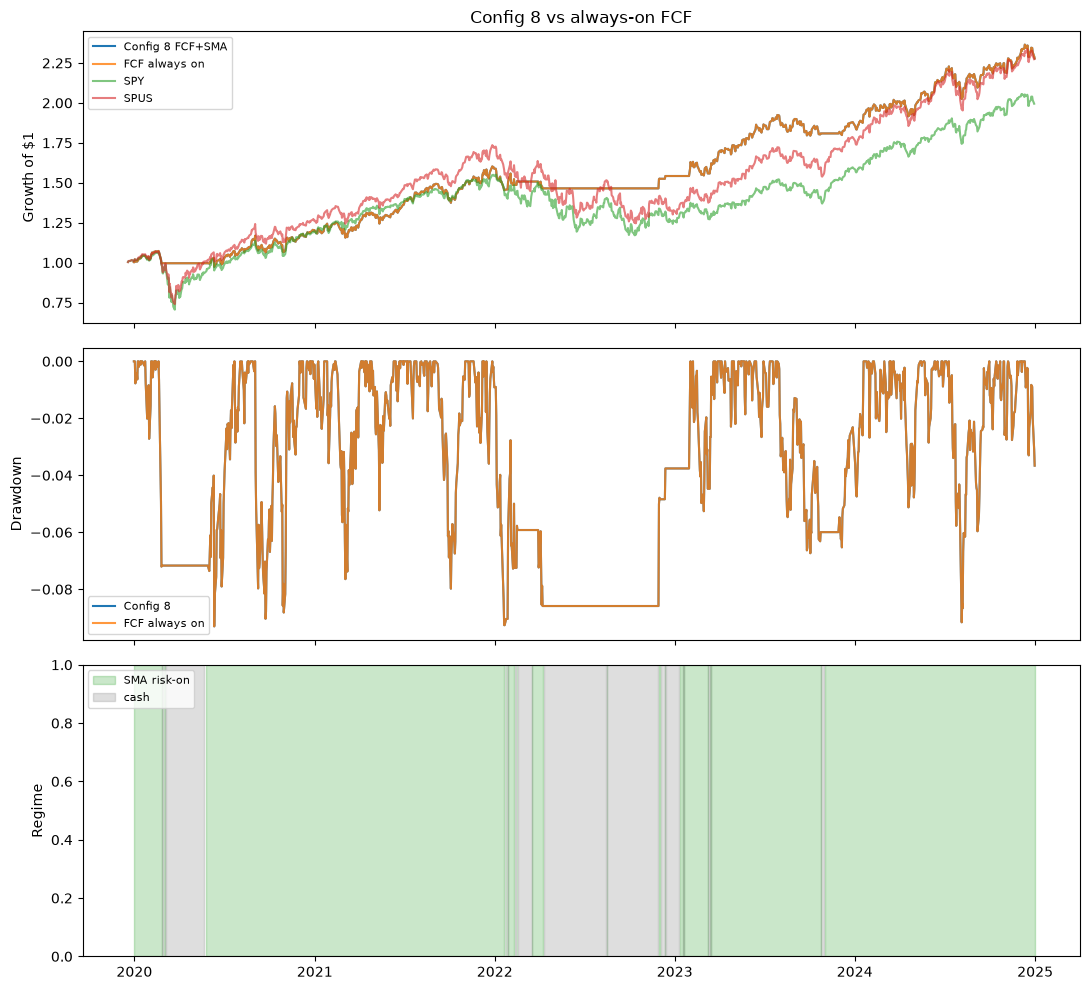

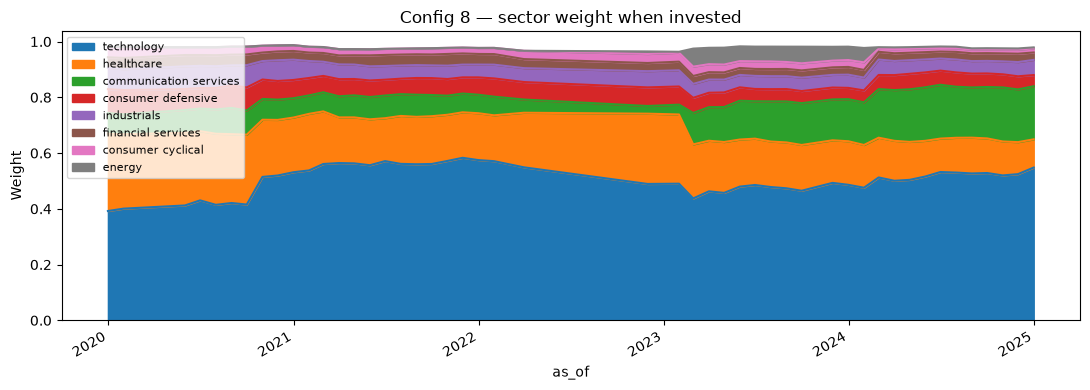

Mean sector weights when invested:


,weight
sector,
technology,50.5%
healthcare,17.8%
communication services,11.3%
consumer defensive,5.8%
industrials,5.4%
financial services,3.2%
consumer cyclical,2.3%
energy,1.4%
basic materials,1.1%


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

eq = (1 + live).cumprod()
eq_on = (1 + sl(fcf_on, START, END)).cumprod()
eq_spy = (1 + spy).cumprod()
eq_spus = (1 + spus).cumprod()
axes[0].plot(eq.index, eq.values, label="Config 8 FCF+SMA")
axes[0].plot(eq_on.index, eq_on.values, label="FCF always on", alpha=0.8)
axes[0].plot(eq_spy.index, eq_spy.values, label="SPY", alpha=0.6)
axes[0].plot(eq_spus.index, eq_spus.values, label="SPUS", alpha=0.6)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Config 8 vs always-on FCF")
axes[0].legend(fontsize=8)

dd = eq / eq.cummax() - 1
dd_on = eq_on / eq_on.cummax() - 1
axes[1].plot(dd.index, dd.values, label="Config 8")
axes[1].plot(dd_on.index, dd_on.values, label="FCF always on", alpha=0.8)
axes[1].set_ylabel("Drawdown")
axes[1].legend(fontsize=8)

reg_plot = regime.reindex(live.index, method="ffill")
axes[2].fill_between(reg_plot.index, 0, 1, where=reg_plot.values, color="tab:green", alpha=0.25, label="SMA risk-on")
axes[2].fill_between(reg_plot.index, 0, 1, where=~reg_plot.fillna(False).values, color="tab:gray", alpha=0.25, label="cash")
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("Regime")
axes[2].legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "config8-path-regime.png", dpi=140)
plt.show()

# sector through time
if not base_log.empty:
    mix = base_log.copy()
    mix["as_of"] = pd.to_datetime(mix["as_of"])
    mix["sector"] = mix["symbol"].map(sector_map).fillna("Unclassified")
    sec = mix.groupby(["as_of", "sector"])["weight"].sum().unstack(fill_value=0.0)
    sec = sec.div(sec.sum(axis=1), axis=0)
    top_sec = sec.mean().sort_values(ascending=False).head(8).index
    ax = sec[top_sec].plot.area(figsize=(11, 4), title="Config 8 — sector weight when invested")
    ax.set_ylabel("Weight")
    ax.legend(fontsize=8, loc="upper left")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "config8-sector-mix.png", dpi=140)
    plt.show()
    print("Mean sector weights when invested:")
    display(sec.mean().sort_values(ascending=False).to_frame("weight").head(10).style.format("{:.1%}"))


## Step 5 — Name-cap ladder

Same FCF engine, same SMA. Caps at 15%, 10%, 8%, 5%, plus uncapped. Train/test split is the same as the blend search. A cap **wins on risk** if it cuts mean top-5 and does not make train max DD or CVaR worse than uncapped config 8 by a meaningful amount.


In [6]:
rows = []
series_caps = {}
logs = {}

for cap in CAPS:
    label = "uncapped" if cap is None else f"cap {cap:.0%}"
    print(f"Running {label} …", flush=True)
    ret, log = lab.book(sleeve_weights=ENGINE_WEIGHTS, name_cap=cap, throttle=THROTTLE).run(start=START)
    s = to_series(ret)
    full = sl(s, START, END)
    train = sl(s, TRAIN_START, TRAIN_END)
    test = sl(s, TEST_START, TEST_END)
    vs_spy = beta_capture(full, spy)
    conc = conc_from_log(log)
    st_full = calc_performance_stats(full, label, rf=RISK_FREE_RATE)
    st_train = calc_performance_stats(train, label, rf=RISK_FREE_RATE)
    st_test = calc_performance_stats(test, label, rf=RISK_FREE_RATE)
    row = {
        "book": label,
        "name_cap": cap,
        "ret_2020": calendar_return(s, 2020),
        "ret_2022": calendar_return(s, 2022),
        "ret_2023": calendar_return(s, 2023),
        "ret_2024": calendar_return(s, 2024),
        "full_cagr": st_full["CAGR"],
        "full_vol": st_full["Volatility"],
        "full_sharpe": st_full["Sharpe"],
        "full_max_dd": st_full["Max Drawdown"],
        "full_calmar": st_full["Calmar"],
        "cvar_5": cvar(full),
        "ulcer": ulcer(full),
        "beta_spy": vs_spy["beta"],
        "down_cap": vs_spy["down_cap"],
        "up_cap": vs_spy["up_cap"],
        "train_max_dd": st_train["Max Drawdown"],
        "train_calmar": st_train["Calmar"],
        "test_cagr": st_test["CAGR"],
        "test_max_dd": st_test["Max Drawdown"],
        "top1": conc["top1"],
        "top5": conc["top5"],
        "hhi": conc["hhi"],
        "eff_n": conc["eff_n"],
        "n_names": conc["n_names"],
    }
    rows.append(row)
    series_caps[label] = s
    logs[label] = log
    print(
        f"  DD {row['full_max_dd']:.1%}  CVaR {row['cvar_5']:.2%}  "
        f"top5 {row['top5']:.1%}  Calmar {row['full_calmar']:.2f}"
    )

ladder = pd.DataFrame(rows)
show = ladder.copy()
pct_cols = [
    "ret_2020", "ret_2022", "ret_2023", "ret_2024",
    "full_cagr", "full_vol", "full_max_dd", "cvar_5", "ulcer",
    "train_max_dd", "test_cagr", "test_max_dd", "top1", "top5",
]
for c in pct_cols:
    show[c] = show[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
for c in ("full_sharpe", "full_calmar", "beta_spy", "down_cap", "up_cap", "train_calmar", "hhi", "eff_n", "n_names"):
    show[c] = show[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
display(show.drop(columns=["name_cap"]))
ladder.to_csv(NB_DIR / "name_cap_ladder.csv", index=False)
print("Wrote name_cap_ladder.csv")


Running uncapped …
  DD -9.3%  CVaR -2.08%  top5 47.6%  Calmar 1.93
Running cap 15% …
  DD -9.4%  CVaR -2.05%  top5 45.0%  Calmar 1.89
Running cap 10% …
  DD -9.5%  CVaR -1.99%  top5 37.2%  Calmar 1.77
Running cap 8% …
  DD -9.6%  CVaR -1.95%  top5 32.5%  Calmar 1.69
Running cap 5% …
  DD -9.7%  CVaR -1.87%  top5 23.8%  Calmar 1.55


,book,ret_2020,ret_2022,ret_2023,ret_2024,full_cagr,full_vol,full_sharpe,full_max_dd,full_calmar,...,up_cap,train_max_dd,train_calmar,test_cagr,test_max_dd,top1,top5,hhi,eff_n,n_names
0,uncapped,20.1%,-2.9%,21.6%,21.5%,17.9%,13.6%,1.13,-9.3%,1.93,...,0.61,-9.3%,1.66,21.6%,-9.2%,17.8%,47.6%,0.07,14.87,110.04
1,cap 15%,19.7%,-3.1%,21.6%,21.4%,17.7%,13.5%,1.13,-9.4%,1.89,...,0.61,-9.4%,1.61,21.6%,-8.9%,15.0%,45.0%,0.06,17.17,110.04
2,cap 10%,18.3%,-3.4%,20.7%,20.8%,16.8%,13.0%,1.10,-9.5%,1.77,...,0.59,-9.5%,1.48,20.8%,-7.8%,10.0%,37.2%,0.04,25.45,110.04
3,cap 8%,17.7%,-3.3%,19.4%,19.9%,16.1%,12.7%,1.08,-9.6%,1.69,...,0.58,-9.6%,1.43,19.8%,-7.4%,8.0%,32.5%,0.03,31.33,110.04
4,cap 5%,16.8%,-2.6%,16.9%,17.4%,14.9%,12.2%,1.04,-9.7%,1.55,...,0.56,-9.7%,1.39,17.2%,-7.0%,5.0%,23.8%,0.02,43.53,110.04


Wrote name_cap_ladder.csv


## Step 6 — Compare paths and pick a cap


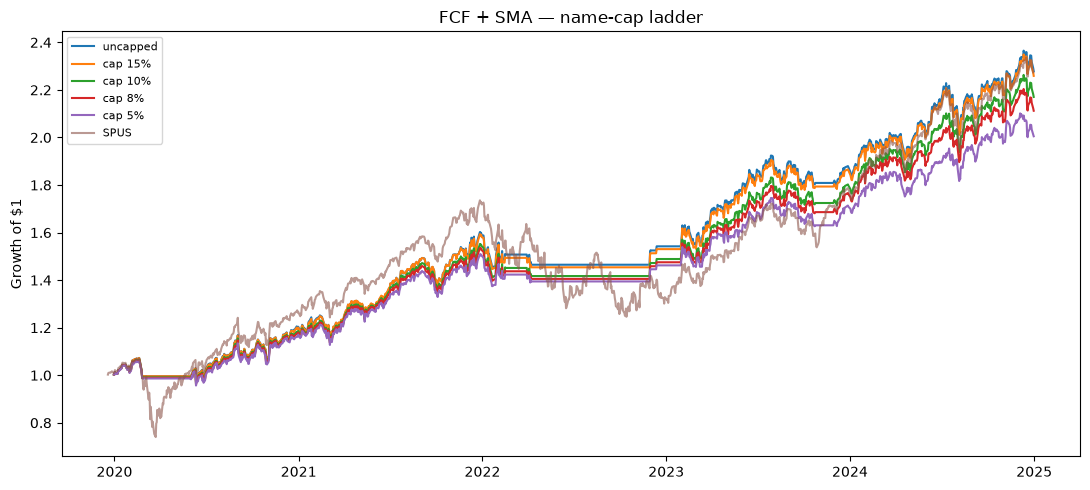

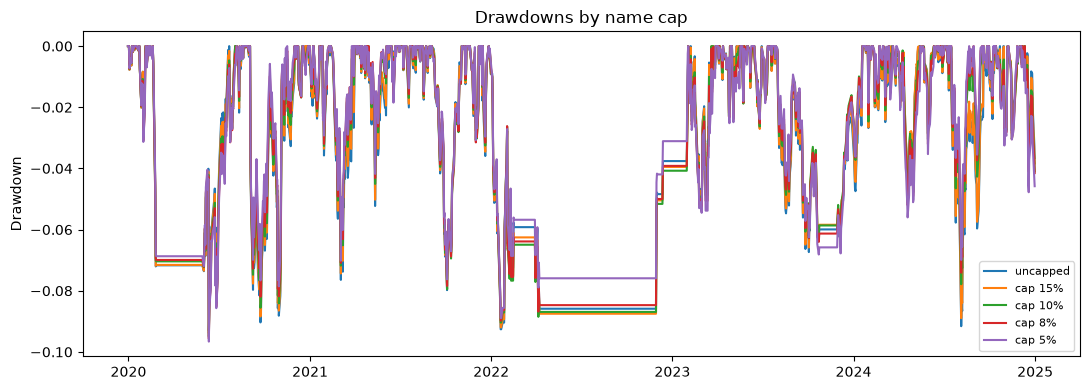

Risk pass (DD/CVaR vs uncapped) and concentration cut:


,book,top5,train_max_dd,cvar_5,full_calmar,dd_ok,cvar_ok,conc_better,risk_pass
0,uncapped,0.476071,-0.093022,-0.020774,1.926594,True,True,False,True
1,cap 15%,0.450252,-0.093896,-0.020487,1.887130,True,True,False,True
2,cap 10%,0.372286,-0.094970,-0.019931,1.766912,True,True,True,True
3,cap 8%,0.325147,-0.095668,-0.019511,1.687913,True,True,True,True
4,cap 5%,0.238199,-0.096627,-0.018746,1.546405,True,True,True,True



PAPER 08 PICK: cap 10%
  tightest useful cap that still passes the DD/CVaR check, ranked by train Calmar
  full CAGR 16.8%  max DD -9.5%  CVaR -1.99%  top5 37.2%  Calmar 1.77


In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
for label, s in series_caps.items():
    eq = (1 + sl(s, START, END)).cumprod()
    ax.plot(eq.index, eq.values, label=label)
ax.plot((1 + spus).cumprod().index, (1 + spus).cumprod().values, label="SPUS", alpha=0.6)
ax.set_title("FCF + SMA — name-cap ladder")
ax.set_ylabel("Growth of $1")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "cap-ladder-equity.png", dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
for label, s in series_caps.items():
    eq = (1 + sl(s, START, END)).cumprod()
    dd = eq / eq.cummax() - 1
    ax.plot(dd.index, dd.values, label=label)
ax.set_title("Drawdowns by name cap")
ax.set_ylabel("Drawdown")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "cap-ladder-drawdowns.png", dpi=140)
plt.show()

uncap = ladder.loc[ladder["book"] == "uncapped"].iloc[0]
# Risk win: lower top5, train max DD not worse than uncapped by more than 1ppt, CVaR not worse by more than 5bp/day
picks = []
for _, r in ladder.iterrows():
    dd_ok = pd.isna(r["train_max_dd"]) or pd.isna(uncap["train_max_dd"]) or (r["train_max_dd"] >= uncap["train_max_dd"] - 0.01)
    cvar_ok = pd.isna(r["cvar_5"]) or pd.isna(uncap["cvar_5"]) or (r["cvar_5"] >= uncap["cvar_5"] - 0.0005)
    conc_better = pd.notna(r["top5"]) and r["top5"] < uncap["top5"] - 0.03
    picks.append({**r.to_dict(), "dd_ok": dd_ok, "cvar_ok": cvar_ok, "conc_better": conc_better, "risk_pass": dd_ok and cvar_ok})

pick_df = pd.DataFrame(picks)
survivors = pick_df[pick_df["risk_pass"] & pick_df["conc_better"]]
if survivors.empty:
    choice = uncap
    why = "no cap cut top-5 by 3ppt without giving back train DD/CVaR — keep uncapped config 8"
else:
    choice = survivors.sort_values("train_calmar", ascending=False).iloc[0]
    why = "tightest useful cap that still passes the DD/CVaR check, ranked by train Calmar"

print("Risk pass (DD/CVaR vs uncapped) and concentration cut:")
display(pick_df[["book", "top5", "train_max_dd", "cvar_5", "full_calmar", "dd_ok", "cvar_ok", "conc_better", "risk_pass"]])
print("\nPAPER 08 PICK:", choice["book"])
print(" ", why)
print(
    f"  full CAGR {choice['full_cagr']:.1%}  max DD {choice['full_max_dd']:.1%}  "
    f"CVaR {choice['cvar_5']:.2%}  top5 {choice['top5']:.1%}  Calmar {choice['full_calmar']:.2f}"
)


## How to read the pick

- Config 8 **without a cap** is allowed if every cap either fails the tail checks or barely moves top-5.
- **8%** is the default risk-budget number from `FrozenRules` (paper 08 live knob). It should win if it drops top-5 a lot and leaves SMA drawdowns intact.
- **5%** is too tight if Calmar collapses or the book becomes 20+ equal-ish mega-caps of the same sector.
- Sector mix still tech-heavy after a name cap is **not** a fail by itself — Halal screens already deleted banks. Report it; do not add a sector cap in this notebook.

Live rule after this notebook: `FrozenRules().with_book(sleeve_weights={"fcf_quality": 1.0}, throttle="spy_sma", name_cap=<pick>)`.
